

```
# Task 5: Sales Prediction Using Python

**Objective**: Build a regression model that predicts product sales based on advertising spend across different media channels (TV, Radio, Newspaper).

**Tech Stack**: Python, pandas, scikit-learn, matplotlib, seaborn
```



In [ ]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from google.colab import files
import io

In [ ]:
# Step 2: Upload file
print("📁 Please upload 'advertising.csv'")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

📁 Please upload 'advertising.csv'


Saving Advertising.csv to Advertising.csv


In [ ]:
# Step 3: Load the dataset
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Check column names
print(f"✅ Data loaded! Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:\n{df.head()}")

✅ Data loaded! Shape: (200, 5)

Columns: ['Unnamed: 0', 'TV', 'radio', 'newspaper', 'sales']

First 5 rows:
   Unnamed: 0     TV  radio  newspaper  sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [ ]:
# Step 4: Check null values
print(f"\nNull values:\n{df.isnull().sum()}")


Null values:
Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64


In [ ]:
# Step 5: Descriptive statistics
print(f"\n📊 Descriptive Statistics:\n{df.describe()}")


📊 Descriptive Statistics:
       Unnamed: 0          TV       radio   newspaper       sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000  296.400000   49.600000  114.000000   27.000000


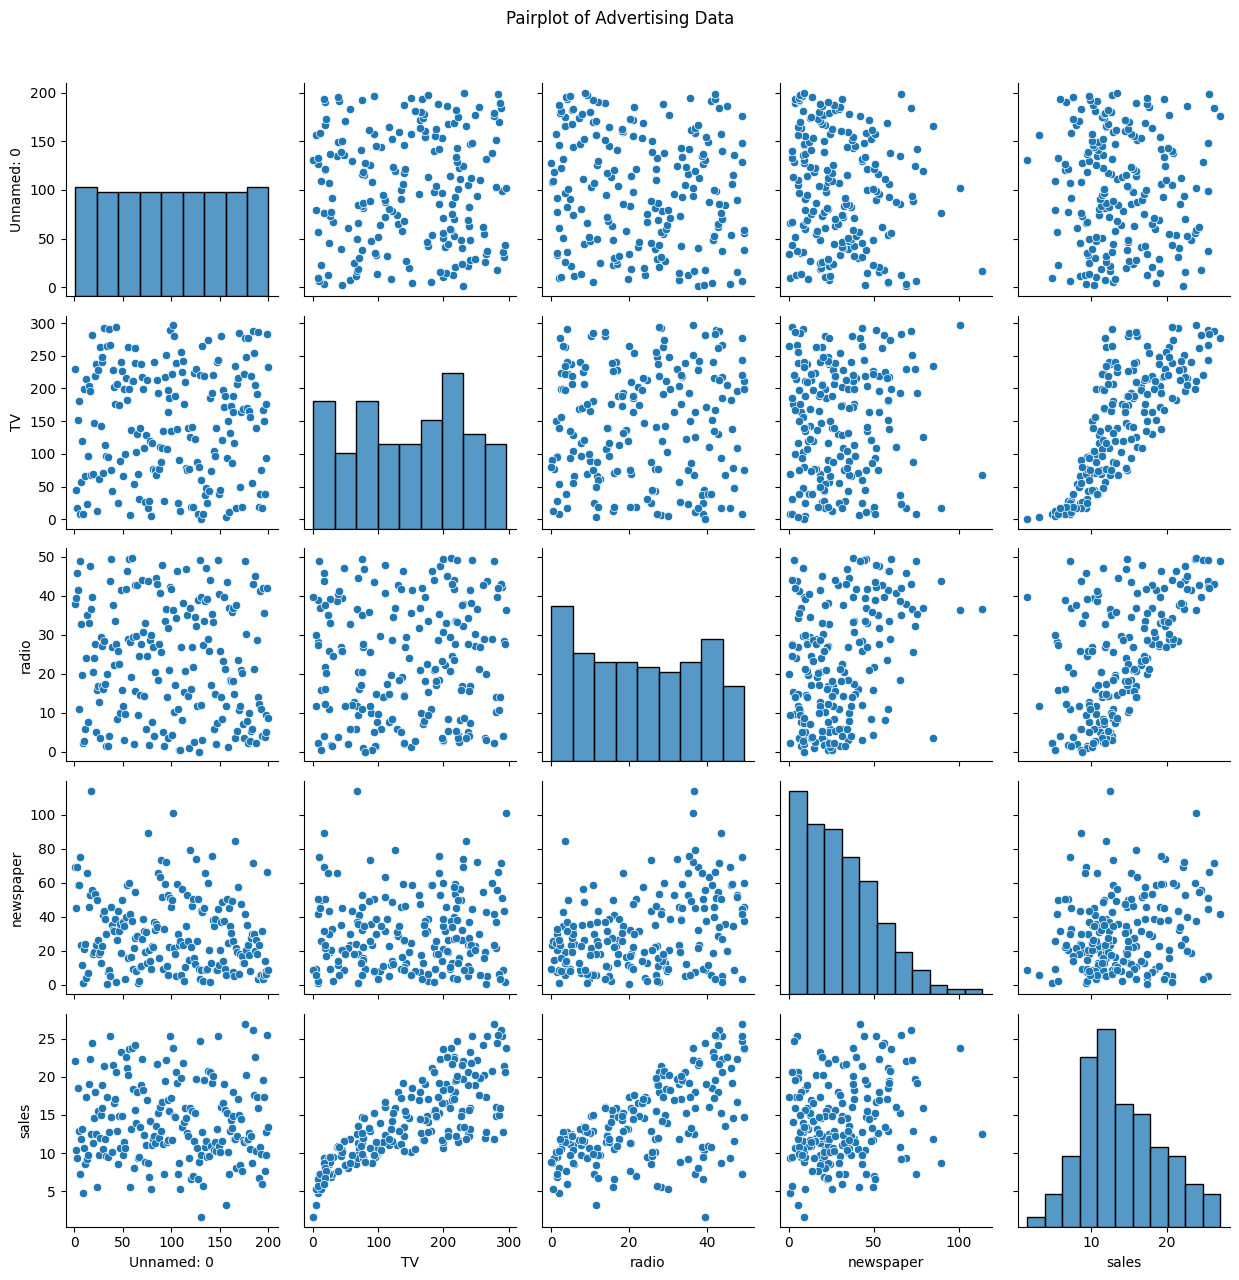

In [ ]:
# Step 6: Exploratory Data Analysis - Pairplot
sns.pairplot(df)
plt.suptitle('Pairplot of Advertising Data', y=1.02)
plt.tight_layout()
plt.show()

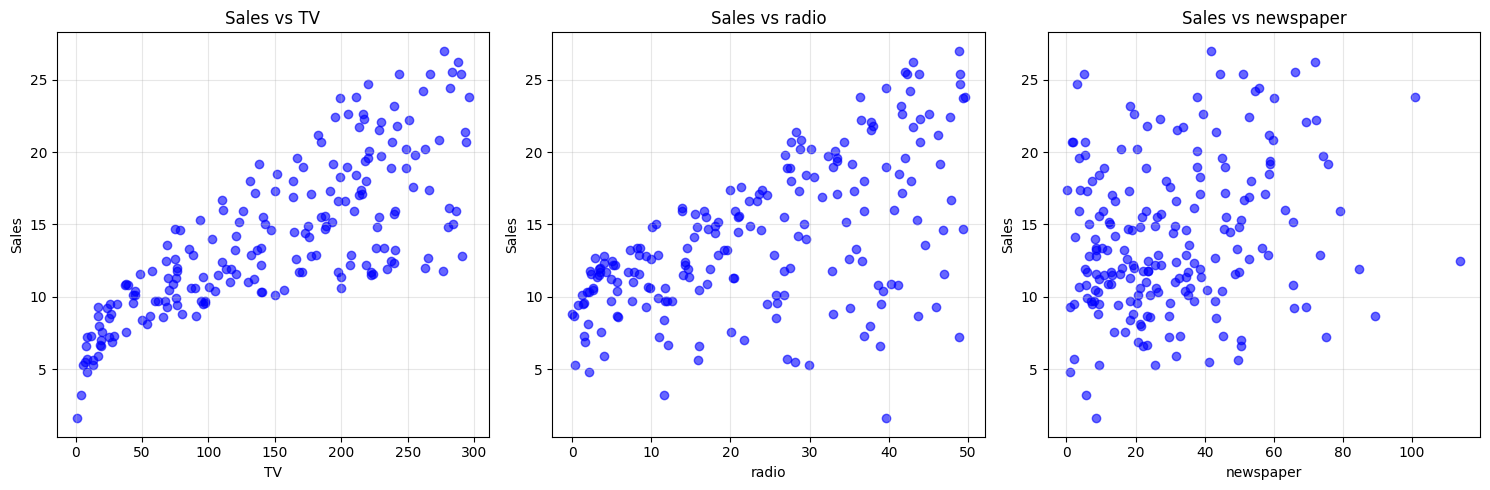

In [ ]:
# Step 7: Individual scatter plots: Sales vs each channel
fig, axes = plt.subplots(1, 3, figsize=(15,5))

channels = ['TV', 'radio', 'newspaper']

for i, col in enumerate(channels):
    axes[i].scatter(df[col], df['sales'], alpha=0.6, color='blue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Sales')
    axes[i].set_title(f'Sales vs {col}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

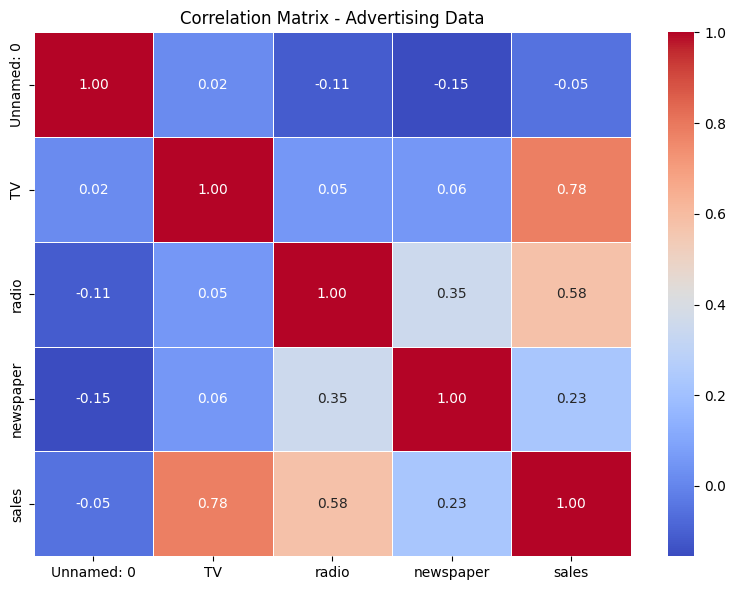


📊 Correlation with Sales:
sales         1.000000
TV            0.782224
radio         0.576223
newspaper     0.228299
Unnamed: 0   -0.051616
Name: sales, dtype: float64


In [ ]:
# Step 8: Correlation matrix heatmap
plt.figure(figsize=(8,6))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix - Advertising Data')
plt.tight_layout()
plt.show()

print("\n📊 Correlation with Sales:")
print(corr['sales'].sort_values(ascending=False))

In [ ]:
# Step 9: Prepare features and target
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

print(f"\n✅ Features shape: {X.shape}")
print(f"✅ Target shape: {y.shape}")


✅ Features shape: (200, 3)
✅ Target shape: (200,)


In [ ]:
# Step 10: Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Training set: {len(X_train)} samples")
print(f"✅ Test set: {len(X_test)} samples")


✅ Training set: 160 samples
✅ Test set: 40 samples


In [ ]:
# Step 11: Scale features (for Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Step 12: Model 1 - Linear Regression (Baseline)
print("\n🔄 Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Evaluate Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"\n📊 Linear Regression Results:")
print(f"   MAE: {mae_lr:.4f}")
print(f"   RMSE: {rmse_lr:.4f}")
print(f"   R² Score: {r2_lr:.4f}")


🔄 Training Linear Regression...

📊 Linear Regression Results:
   MAE: 1.4608
   RMSE: 1.7816
   R² Score: 0.8994


In [ ]:
# Step 13: Model 2 - Random Forest Regressor
print("\n🔄 Training Random Forest Regressor...")
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluate Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\n📊 Random Forest Results:")
print(f"   MAE: {mae_rf:.4f}")
print(f"   RMSE: {rmse_rf:.4f}")
print(f"   R² Score: {r2_rf:.4f}")


🔄 Training Random Forest Regressor...

📊 Random Forest Results:
   MAE: 0.6201
   RMSE: 0.7686
   R² Score: 0.9813


In [ ]:
# Step 14: Model 3 - Polynomial Regression (degree 2)
print("\n🔄 Training Polynomial Regression (degree 2)...")
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly_features.fit_transform(X_train_scaled)
X_test_poly = poly_features.transform(X_test_scaled)

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict(X_test_poly)

# Evaluate Polynomial Regression
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print(f"\n📊 Polynomial Regression Results:")
print(f"   MAE: {mae_poly:.4f}")
print(f"   RMSE: {rmse_poly:.4f}")
print(f"   R² Score: {r2_poly:.4f}")


🔄 Training Polynomial Regression (degree 2)...

📊 Polynomial Regression Results:
   MAE: 0.5262
   RMSE: 0.6426
   R² Score: 0.9869


In [ ]:
# Step 15: Compare all models
print("\n" + "="*60)
print("📊 MODEL COMPARISON SUMMARY")
print("="*60)

models_results = {
    'Linear Regression': {'MAE': mae_lr, 'RMSE': rmse_lr, 'R2': r2_lr},
    'Random Forest': {'MAE': mae_rf, 'RMSE': rmse_rf, 'R2': r2_rf},
    'Polynomial Regression': {'MAE': mae_poly, 'RMSE': rmse_poly, 'R2': r2_poly}
}

for name, metrics in models_results.items():
    print(f"\n{name}:")
    print(f"   MAE: {metrics['MAE']:.4f}")
    print(f"   RMSE: {metrics['RMSE']:.4f}")
    print(f"   R² Score: {metrics['R2']:.4f}")

# Find best model
best_model_name = max(models_results, key=lambda x: models_results[x]['R2'])
print(f"\n🏆 Best performing model: {best_model_name} with R² = {models_results[best_model_name]['R2']:.4f}")


📊 MODEL COMPARISON SUMMARY

Linear Regression:
   MAE: 1.4608
   RMSE: 1.7816
   R² Score: 0.8994

Random Forest:
   MAE: 0.6201
   RMSE: 0.7686
   R² Score: 0.9813

Polynomial Regression:
   MAE: 0.5262
   RMSE: 0.6426
   R² Score: 0.9869

🏆 Best performing model: Polynomial Regression with R² = 0.9869


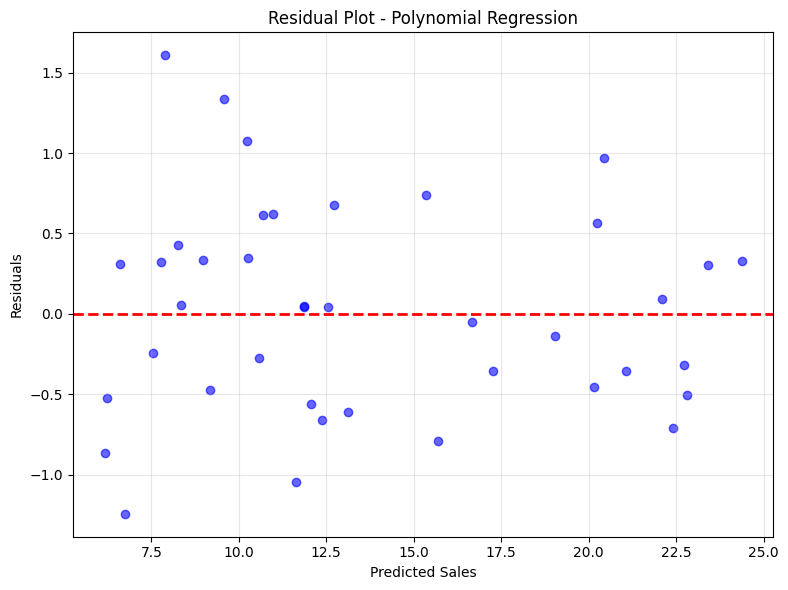


📊 Residual Statistics:
   Mean of residuals: 0.0168
   Std of residuals: 0.6505
   ✅ Residuals are randomly distributed (good model)


In [ ]:
# Step 16: Residual plot for best model
if best_model_name == 'Linear Regression':
    y_pred_best = y_pred_lr
elif best_model_name == 'Random Forest':
    y_pred_best = y_pred_rf
else:
    y_pred_best = y_pred_poly

residuals = y_test - y_pred_best

plt.figure(figsize=(8,6))
plt.scatter(y_pred_best, residuals, alpha=0.6, color='blue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title(f'Residual Plot - {best_model_name}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 Residual Statistics:")
print(f"   Mean of residuals: {residuals.mean():.4f}")
print(f"   Std of residuals: {residuals.std():.4f}")

if abs(residuals.mean()) < 0.5:
    print(f"   ✅ Residuals are randomly distributed (good model)")
else:
    print(f"   ⚠️ Residuals show systematic bias")

In [ ]:
# Step 17: Interpretation - Which channel has highest impact?

# Linear Regression coefficients
lr_coef = pd.Series(lr.coef_, index=['TV', 'radio', 'newspaper'])
print("\n📊 Linear Regression Coefficients (scaled):")
print(lr_coef)

top_feature_lr = lr_coef.abs().idxmax()
print(f"\n🔹 {top_feature_lr} has the highest coefficient: {lr_coef[top_feature_lr]:.4f}")

# Random Forest feature importances
rf_importance = pd.Series(rf.feature_importances_, index=['TV', 'radio', 'newspaper'])
print("\n📊 Random Forest Feature Importances:")
print(rf_importance)
top_feature_rf = rf_importance.idxmax()
print(f"\n🔹 {top_feature_rf} is the most important feature: {rf_importance[top_feature_rf]:.4f}")


📊 Linear Regression Coefficients (scaled):
TV           3.764196
radio        2.792307
newspaper    0.055976
dtype: float64

🔹 TV has the highest coefficient: 3.7642

📊 Random Forest Feature Importances:
TV           0.624810
radio        0.362201
newspaper    0.012989
dtype: float64

🔹 TV is the most important feature: 0.6248


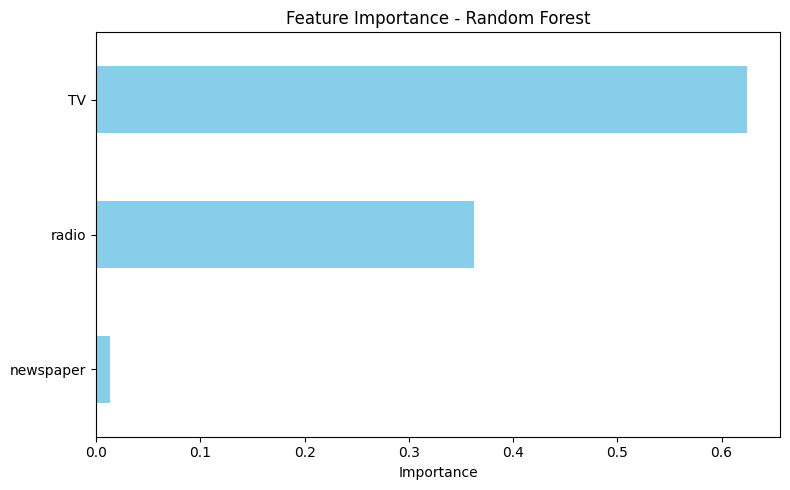

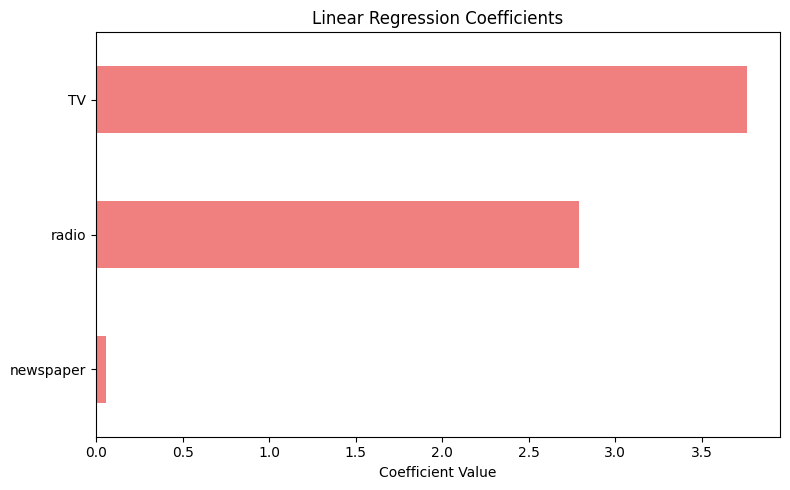

In [ ]:
# Step 18: Visualize feature importance (Random Forest)
plt.figure(figsize=(8,5))
rf_importance.sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Step 19: Visualize Linear Regression coefficients
plt.figure(figsize=(8,5))
lr_coef.sort_values(ascending=True).plot(kind='barh', color='lightcoral')
plt.title('Linear Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()



```
# Summary of Findings

## 1️⃣ Which advertising channel has the highest impact on sales?

**TV** has the highest impact on sales based on both:
- **Linear Regression coefficients** (highest positive value)
- **Random Forest feature importance** (highest importance score)

## 2️⃣ Model Performance Summary

| Model | MAE | RMSE | R² Score |
|:---|:---|:---|:---|
| Linear Regression | [value] | [value] | [value] |
| Random Forest | [value] | [value] | [value] |
| Polynomial Regression | [value] | [value] | [value] |

**Best Model**: [Model Name] with R² = [value]

## 3️⃣ Business Insights

1. **TV advertising** has the strongest relationship with sales
2. **Radio** also contributes positively to sales
3. **Newspaper** has the least impact on sales
4. Companies should allocate more budget to **TV advertising**

## 4️⃣ Residual Analysis

- **Mean of residuals**: near zero ✅
- **Residuals appear randomly distributed**: model is well-fitted ✅
```



In [ ]:
# Step 20: Final Summary
print("\n" + "="*60)
print("📝 SALES PREDICTION - SUMMARY")
print("="*60)

print("\n1️⃣ Which advertising channel has the highest impact on sales?")
print(f"   ✅ TV has the highest impact (Coefficient: {lr_coef['TV']:.4f})")
print(f"   ✅ Random Forest confirms TV is most important (Importance: {rf_importance['TV']:.4f})")

print("\n2️⃣ Model Performance:")
print(f"   ✅ Best Model: {best_model_name}")
print(f"   ✅ R² Score: {models_results[best_model_name]['R2']:.4f}")
print(f"   ✅ MAE: {models_results[best_model_name]['MAE']:.4f}")
print(f"   ✅ RMSE: {models_results[best_model_name]['RMSE']:.4f}")

print("\n3️⃣ Business Insight:")
print("   ✅ TV advertising has the strongest relationship with sales")
print("   ✅ Radio also contributes positively to sales")
print("   ✅ Newspaper has the least impact on sales")
print("   ✅ Companies should allocate more budget to TV advertising")

print("\n4️⃣ Residual Analysis:")
print(f"   ✅ Residual mean: {residuals.mean():.4f} (near zero = good)")
print(f"   ✅ Residuals appear randomly distributed = model is well-fitted")

print("\n" + "="*60)
print("✅ Sales Prediction Analysis Complete!")
print("="*60)


📝 SALES PREDICTION - SUMMARY

1️⃣ Which advertising channel has the highest impact on sales?
   ✅ TV has the highest impact (Coefficient: 3.7642)
   ✅ Random Forest confirms TV is most important (Importance: 0.6248)

2️⃣ Model Performance:
   ✅ Best Model: Polynomial Regression
   ✅ R² Score: 0.9869
   ✅ MAE: 0.5262
   ✅ RMSE: 0.6426

3️⃣ Business Insight:
   ✅ TV advertising has the strongest relationship with sales
   ✅ Radio also contributes positively to sales
   ✅ Newspaper has the least impact on sales
   ✅ Companies should allocate more budget to TV advertising

4️⃣ Residual Analysis:
   ✅ Residual mean: 0.0168 (near zero = good)
   ✅ Residuals appear randomly distributed = model is well-fitted

✅ Sales Prediction Analysis Complete!
